In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
%matplotlib widget
    
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


2023-10-04 23:07:12.973701: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Tensorflow not install, you could not use those pipelines
To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


In [2]:
from moabb.paradigms import P300
from moabb.datasets import BNCI2014_008, BNCI2014_009, EPFLP300
plt.style.use('default')

fmax=16
sfreq=32 
paradigm = P300(resample=sfreq, tmin=-0.2, tmax=1.0, fmin=0.5, fmax=fmax)
dataset = EPFLP300()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)

Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
3317 matching events found
No baseline correction applied


/data/.virtualenvs/hoda/lib/python3.11/site-packages/moabb/paradigms/base.py:346: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [3]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

tl.set_backend('numpy')

X = epochs.get_data()
y = labels

X.shape

(3317, 32, 26)

In [4]:
from hoda.hoda import BTTDA
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler

n_blocks=3
bttda = BTTDA(
    n_blocks=n_blocks,
    hoda_params=dict(
            rank=None,
            max_iter=32,
            tol=1e-12,
            init ='svd',
            shrinkage=('lw','lw'),
            toeplitz=None,
            obj='tr',
            solver='lanczos',
            taper=False,
            keep_train_info=True,
            verbose=True,
            lasso=True
    ),
    keep_train_info=True,
    verbose=True)                   

bttda.fit(X,y)

Fitting block 1/3...
Initializing factors...
Fitting discriminative tucker model...


  0%|          | 0/32 [00:00<?, ?it/s]

Fitted tucker model of rank [5, 2] ...

Fitting block 2/3...
Initializing factors...
Fitting discriminative tucker model...


  0%|          | 0/32 [00:00<?, ?it/s]

Fitted tucker model of rank [6, 1] ...

Fitting block 3/3...
Initializing factors...
Fitting discriminative tucker model...


  0%|          | 0/32 [00:00<?, ?it/s]

Fitted tucker model of rank [1, 2] ...



BTTDA(hoda_params={'init': 'svd', 'keep_train_info': True, 'lasso': True,
                   'max_iter': 32, 'obj': 'tr', 'rank': None,
                   'shrinkage': ('lw', 'lw'), 'solver': 'lanczos',
                   'taper': False, 'toeplitz': None, 'tol': 1e-12,
                   'verbose': True},
      keep_train_info=True, n_blocks=3, verbose=True)

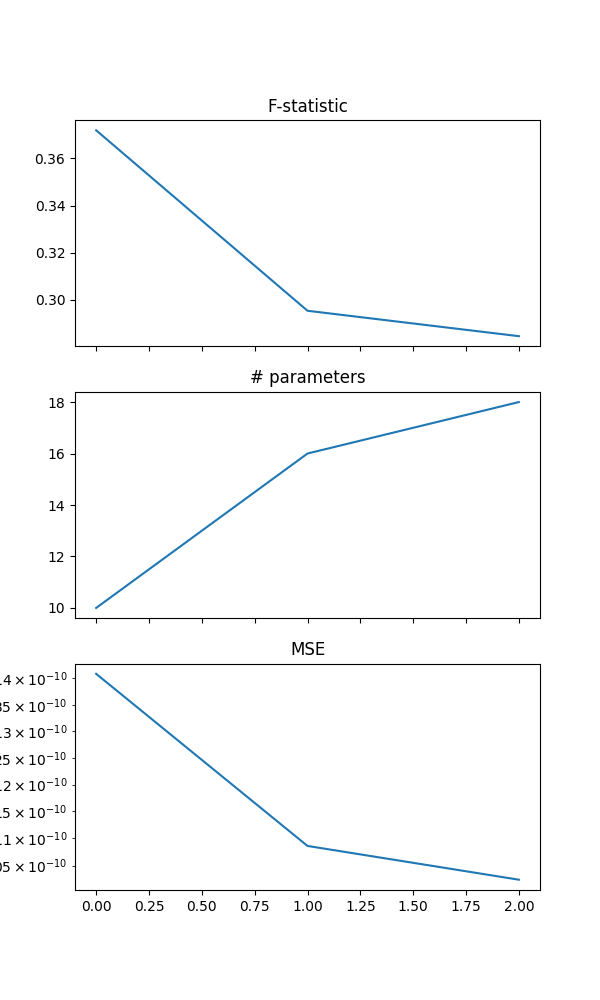

In [5]:
fig, axs = plt.subplots(3,1, sharex=True, figsize=(6,10))

axs[0].set_title('F-statistic')
axs[0].plot(bttda.train_info_["f_stat"])

axs[1].set_title('# parameters')
axs[1].plot(bttda.train_info_["n_params"])

axs[2].set_title('MSE')
axs[2].semilogy(bttda.train_info_["mse"])



In [6]:
import cupy

"""
fig, axs = plt.subplots(n_blocks, 2, figsize=(8,16))
for b in range(len(bttda.blocks_)):
    for k in range(2):
        scatter_w = cupy.asnumpy(bttda.blocks_[b].scatter_w_[k])
        vmax = np.max(np.abs(scatter_w))
        sns.heatmap(scatter_w, cmap='BrBG',
                    vmin=-vmax, vmax=vmax, ax=axs[b,k])    
        axs[b,k].set_aspect('equal')
"""

"\nfig, axs = plt.subplots(n_blocks, 2, figsize=(8,16))\nfor b in range(len(bttda.blocks_)):\n    for k in range(2):\n        scatter_w = cupy.asnumpy(bttda.blocks_[b].scatter_w_[k])\n        vmax = np.max(np.abs(scatter_w))\n        sns.heatmap(scatter_w, cmap='BrBG',\n                    vmin=-vmax, vmax=vmax, ax=axs[b,k])    \n        axs[b,k].set_aspect('equal')\n"

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


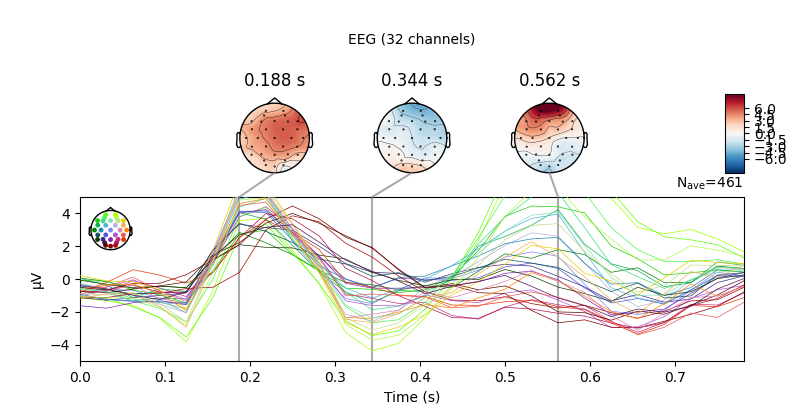

In [7]:
joint_args=dict(ts_args=dict(ylim=dict(eeg=[-5,5])))


target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
contrast = combine_evoked([target,non_target], weights=[1,-1])
_ = contrast.plot_joint(**joint_args)

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


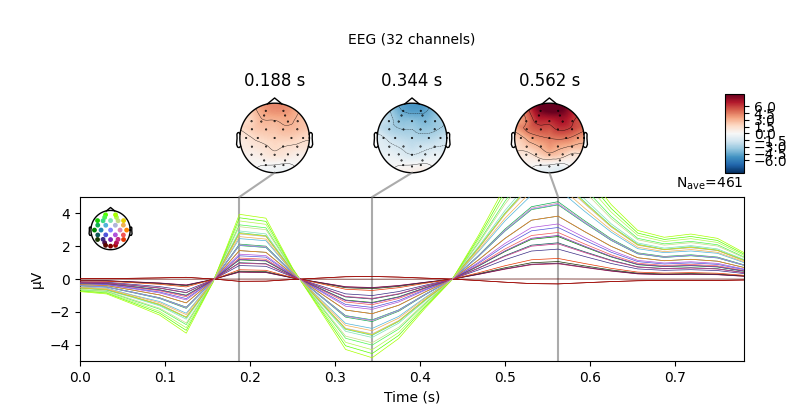

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


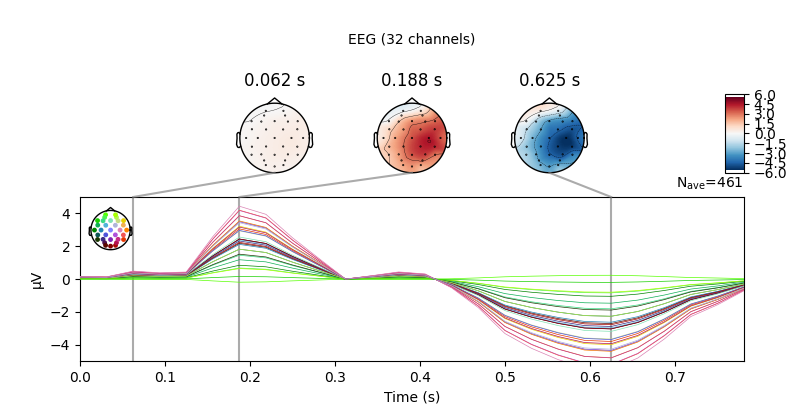

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


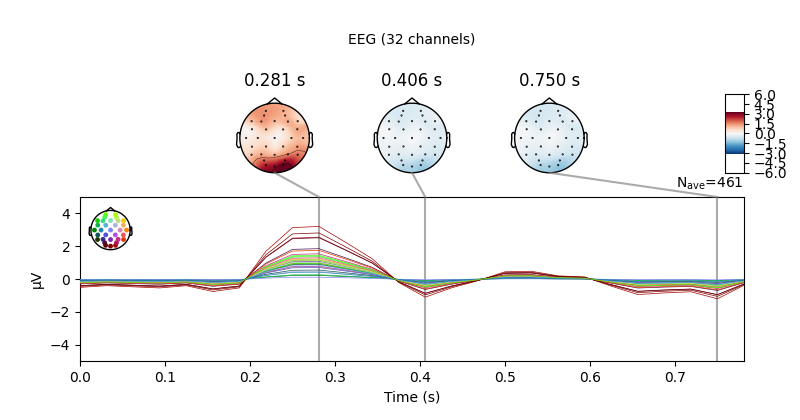

In [8]:
from mne import combine_evoked

for b in range(len(bttda.blocks_)):
    epochs_rec = epochs.copy()
    epochs_rec._data = bttda.blocks_[b].inv_transform(bttda.blocks_[b].transform(epochs_rec.get_data()))
    
    target = epochs_rec['Target'].average()
    non_target = epochs_rec['NonTarget'].average()
    contrast = combine_evoked([target,non_target], weights=[1,-1])
    _ = contrast.plot_joint(**joint_args)


/data/.virtualenvs/hoda/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


0.871678484773653


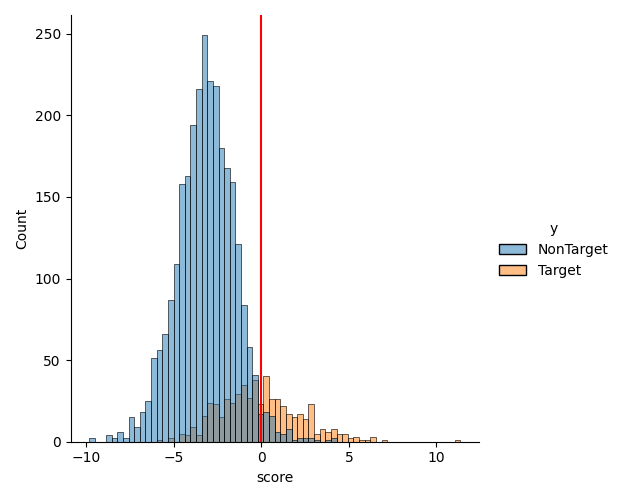

In [9]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
import pandas as pd

Xt = bttda.transform(X)
Xt_flat = cupy.asnumpy(Xt.reshape((Xt.shape[0],-1)))
lda = LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr') 
lda.fit(Xt_flat, y)
score_pred = lda.decision_function(Xt_flat)
df = pd.DataFrame(dict(score=score_pred,y=y))
sns.displot(df, x='score', hue='y')
plt.axvline(0, color='red')
print(roc_auc_score(y,score_pred))